In [89]:
import datalair
from pathlib import Path
import anndata as ad
import numpy as np
import pandas as pd

storage_path = Path("/Users/halu/remote_connections/olm/storage/halu").resolve()
assert storage_path.exists()
lair = datalair.Lair(storage_path / "lair")
lair.assert_ok_satus()

In [49]:
path = storage_path / "manual-download/MFP/data/"
path.exists()

True

In [67]:
fast_storage_path = Path("/Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM").resolve()
assert fast_storage_path.exists()
fractions_list = []
fails = list()
for i, file in enumerate(fast_storage_path.glob("*.h5ad")):
    print(i, file)
    try:
        adata = ad.read_h5ad(file)
    except:
        print("failed")
        fails.append(file)
        continue
    fractions = adata.to_df().T.sum()
    fractions = fractions / fractions.sum()
    fractions.name = file.stem
    fractions_list.append(fractions)
df = pd.concat(fractions_list, axis=1).T
df.head()

0 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-YD-A9TA-06A-11R-A39D-07.h5ad
1 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-FS-A1Z4-06A-11R-A18T-07.h5ad
2 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-EE-A20B-06A-11R-A18U-07.h5ad
3 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-GN-A26A-06A-11R-A18T-07.h5ad
4 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-D3-A2JO-06A-11R-A18S-07.h5ad
5 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-ER-A19T-06A-11R-A18U-07.h5ad
6 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-EE-A2MI-06A-11R-A18U-07.h5ad
7 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-EB-A1NK-01A-11R-A18T-07.h5ad
8 /Users/halu/remote_connections/olm/fast-storage/hotspots/deconvolutions/SKCM/TCGA-HR-A2OH-06A-

,B cells,CD8+ T cells,Melanoma cells_tumor71,Melanoma cells_tumor81,Melanoma cells_tumor80,CD4+ T cells,Macrophages/Monocytes,regulatory T cells,Cancer associated fibroblasts,Dendritic cells,...,Melanoma cells_tumor82,Melanoma cells_tumor53,Melanoma cells_tumor59,Melanoma cells_tumor65,Melanoma cells_tumor78,Melanoma cells_tumor84,Melanoma cells_tumor60,Melanoma cells_tumor88,Melanoma cells_tumor89,Melanoma cells_tumor94
TCGA-YD-A9TA-06A-11R-A39D-07,0.004537,0.100108,7.577409e-07,2.407301e-04,0.004363,0.000088,0.021256,0.005314,0.348130,0.004582,...,0.060439,0.001220,6.365827e-07,0.045921,0.001072,0.063193,0.071465,0.000007,0.000210,0.009250
TCGA-FS-A1Z4-06A-11R-A18T-07,0.046471,0.080764,3.846699e-05,2.695685e-06,0.042412,0.000025,0.024980,0.086105,0.162139,0.001889,...,0.046722,0.000464,1.246942e-06,0.036884,0.022331,0.163279,0.057338,0.000172,0.000174,0.013104
TCGA-EE-A20B-06A-11R-A18U-07,0.000210,0.006126,1.337428e-03,1.870078e-02,0.039933,0.000007,0.021284,0.003313,0.274381,0.000031,...,0.188590,0.001409,2.061949e-12,0.012769,0.006361,0.047814,0.004517,0.016071,0.000403,0.071212
TCGA-GN-A26A-06A-11R-A18T-07,0.000015,0.005733,3.627444e-11,2.443807e-03,0.015041,0.000003,0.058029,0.005846,0.312839,0.000011,...,0.280377,0.000613,1.016514e-17,0.000043,0.000006,0.006682,0.000060,0.000005,0.000057,0.004003
TCGA-D3-A2JO-06A-11R-A18S-07,0.000601,0.056497,6.001478e-09,2.938647e-07,0.070154,0.000007,0.086319,0.036999,0.093468,0.000320,...,0.054124,0.002344,5.777920e-11,0.023974,0.064087,0.109795,0.174149,0.005162,0.001532,0.006559


In [69]:
df.to_csv("../data/skcm_fractions.csv", index=True, header=True, sep=",")

In [76]:
classified_skcm_path = Path("/Users/halu/remote_connections/olm/storage/halu/manual-download/MFP/data/TCGA-AllProjectsAdata/ordered_classified_samples/SKCM.csv")
assert classified_skcm_path.exists()
classes_skcm = pd.read_csv(classified_skcm_path, index_col=0, header=0)

In [91]:
df = df.loc[list(set(df.index).intersection(set(classes_skcm.index)))]
df = df.sort_index()
classes_skcm = classes_skcm.sort_index()
assert np.all(df.index == classes_skcm.index)

In [124]:
means = df.groupby(classes_skcm.MFP).mean().T
errors = df.groupby(classes_skcm.MFP).std().div(np.sqrt(df.groupby(classes_skcm.MFP).count())).T

immune_cells = ['B cells', 'CD8+ T cells', 'CD4+ T cells',
       'Macrophages/Monocytes', 'regulatory T cells',
       'Cancer associated fibroblasts', 'Dendritic cells', 'Endothelial cells',
       'Natural killer cells']
means = means.loc[immune_cells]
errors = errors.loc[immune_cells]

In [125]:
errors

MFP,D,F,IE,IE/F
B cells,0.000322,0.000237,0.003361,0.006018
CD8+ T cells,0.001014,0.000768,0.003537,0.002579
CD4+ T cells,0.000316,0.000619,0.000085,0.000929
Macrophages/Monocytes,0.001226,0.001303,0.004926,0.006431
regulatory T cells,0.000847,0.000526,0.002294,0.003493
Cancer associated fibroblasts,0.004599,0.009558,0.004711,0.012328
Dendritic cells,0.000156,0.000875,0.000560,0.002072
Endothelial cells,0.005736,0.003529,0.003217,0.006233
Natural killer cells,0.000134,0.000072,0.000210,0.000414


In [126]:
means

MFP,D,F,IE,IE/F
B cells,0.000966,0.001133,0.012286,0.020083
CD8+ T cells,0.005497,0.005813,0.042805,0.018860
CD4+ T cells,0.000513,0.001988,0.000179,0.001621
Macrophages/Monocytes,0.006816,0.013477,0.065348,0.055193
regulatory T cells,0.004234,0.004515,0.024964,0.021870
Cancer associated fibroblasts,0.047636,0.187925,0.078023,0.165580
Dendritic cells,0.000278,0.004582,0.001838,0.006927
Endothelial cells,0.107018,0.124728,0.122478,0.144010
Natural killer cells,0.000829,0.000782,0.002504,0.003310


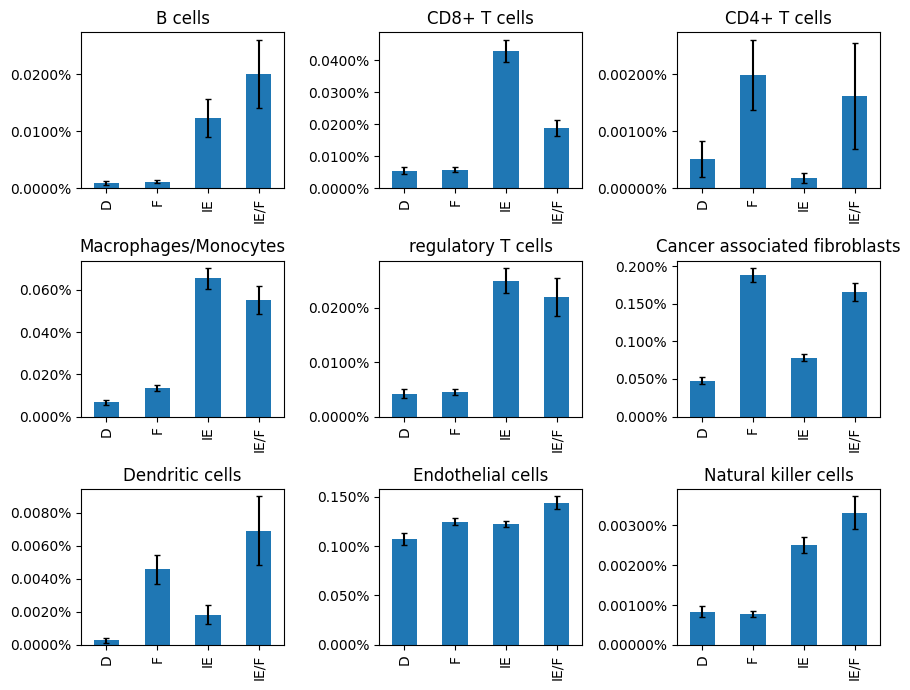

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Assuming 'means' is your DataFrame
# For demonstration, creating a dummy 'means' DataFrame:
# means = pd.DataFrame(data, index=['Row 1', 'Row 2', ...])

# Configuration for subplots
num_plots = len(means)
cols = 3  # Set number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate required rows

# Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(9, 7))
axes = axes.flatten()  # Flatten to iterate easily

for i, ((index, row), (_, row_error)) in enumerate(zip(means.iterrows(), errors.iterrows())):
    # Sort the bars in descending order
    sorted_row = row#.sort_values(ascending=False)

    # Plot on the corresponding subplot
    sorted_row.plot(kind='bar', ax=axes[i], yerr=row_error, capsize=2)

    # Labeling
    axes[i].set_title(index)
    axes[i].set_ylabel(None)
    axes[i].set_xlabel(None)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    # axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots if the grid is larger than the number of rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

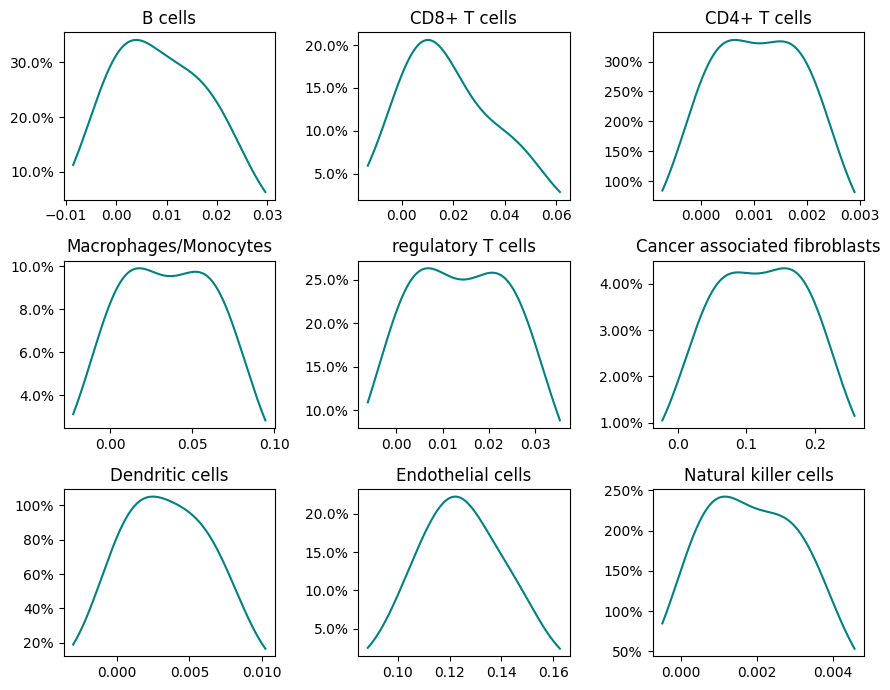

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Assuming 'means' is your DataFrame
# For demonstration, creating a dummy 'means' DataFrame:
# means = pd.DataFrame(data, index=['Row 1', 'Row 2', ...])

# Configuration for subplots
num_plots = len(means)
cols = 3  # Set number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate required rows

# Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(9, 7))
axes = axes.flatten()  # Flatten to iterate easily

for i, ((index, row), (_, row_error)) in enumerate(zip(means.iterrows(), errors.iterrows())):
    # Sort the bars in descending order
    sorted_row = row#.sort_values(ascending=False)

    # Plot on the corresponding subplot
    sorted_row.plot(kind='kde', ax=axes[i], color='teal')

    # Labeling
    axes[i].set_title(index)
    axes[i].set_ylabel(None)
    axes[i].set_xlabel(None)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    # axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots if the grid is larger than the number of rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [142]:
df.groupby(classes_skcm.MFP).unstack().plot(kind='kde', subplots=True, layout=(3, 3), sharex=False)

AttributeError: 'DataFrameGroupBy' object has no attribute 'unstack'

In [156]:
classes_skcm.MFP.unique()

array(['F', 'IE', 'IE/F', 'D'], dtype=object)

B cells
F
IE
IE/F
D


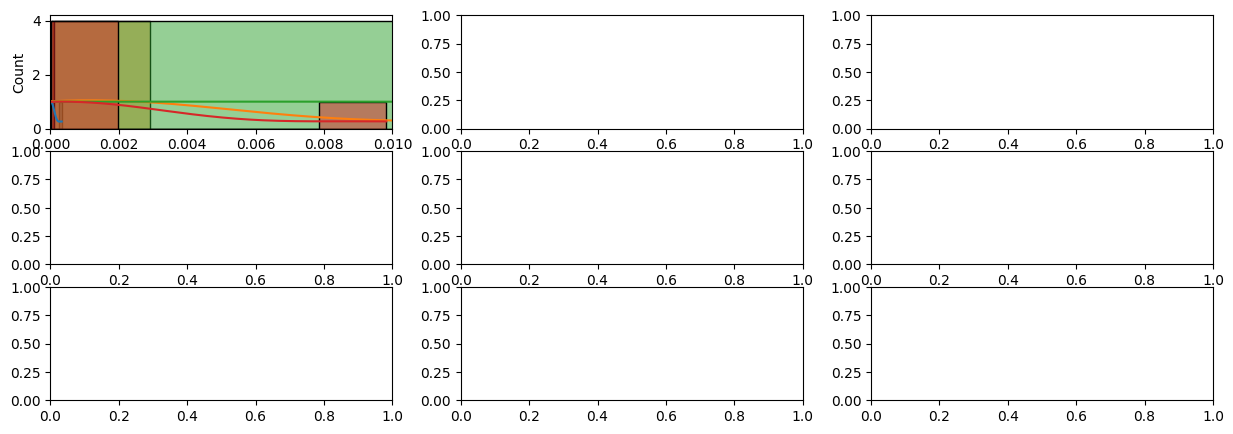

In [162]:
import seaborn as sns
fig, axes = plt.subplots(3, 3, figsize=(15, 5))
axes = np.ndarray.flatten(axes)
for (name, group), ax in zip(df.T.iterrows(), axes):
    print(name)
    for subtype in classes_skcm.MFP.unique():
        print(subtype)
        sns.histplot(data=group[classes_skcm.MFP==subtype].head(), ax=ax, kde=True)
        ax.set_xlim(0, 0.01)
    break

In [152]:
df.T

,TCGA-3N-A9WB-06A-11R-A38C-07,TCGA-3N-A9WC-06A-11R-A38C-07,TCGA-3N-A9WD-06A-11R-A38C-07,TCGA-BF-A1PU-01A-11R-A18S-07,TCGA-BF-A1PV-01A-11R-A18U-07,TCGA-BF-A1PX-01A-12R-A18T-07,TCGA-BF-A1PZ-01A-11R-A18S-07,TCGA-BF-A1Q0-01A-21R-A18S-07,TCGA-BF-A3DJ-01A-11R-A20F-07,TCGA-BF-A3DL-01A-11R-A20F-07,...,TCGA-XV-AB01-06A-12R-A40A-07,TCGA-YD-A89C-06A-11R-A37K-07,TCGA-YD-A9TA-06A-11R-A39D-07,TCGA-YD-A9TB-06A-12R-A40A-07,TCGA-YG-AA3N-01A-11R-A38C-07,TCGA-YG-AA3O-06A-11R-A38C-07,TCGA-YG-AA3P-06A-11R-A38C-07,TCGA-Z2-A8RT-06AR-A37K-07-A37K-07,TCGA-Z2-AA3S-06A-11R-A39D-07,TCGA-Z2-AA3V-06A-11R-A39D-07
B cells,1.835914e-05,8.264982e-04,2.607105e-01,9.461780e-06,7.820039e-06,5.135746e-04,1.179505e-05,9.820766e-03,3.285773e-04,3.423420e-06,...,0.007385,0.000683,4.537231e-03,3.315375e-04,1.030419e-03,6.014810e-04,0.002045,1.255653e-02,0.008463,1.815342e-06
CD8+ T cells,2.166954e-04,7.356042e-02,6.994815e-05,4.906341e-05,1.665892e-04,1.847416e-02,5.536688e-04,1.084353e-02,2.586561e-03,3.568657e-05,...,0.000413,0.001752,1.001078e-01,8.289519e-03,1.479823e-02,9.460232e-03,0.001437,1.614658e-02,0.015123,2.857003e-03
Melanoma cells_tumor71,2.841310e-07,3.660066e-06,5.702560e-11,1.761355e-09,8.033825e-07,4.055765e-12,9.338107e-08,2.985743e-08,5.014980e-15,8.472216e-12,...,0.000009,0.046172,7.577409e-07,6.363309e-07,6.591523e-11,5.731981e-08,0.052868,4.393872e-05,0.006949,2.450102e-07
Melanoma cells_tumor81,3.314042e-08,1.906672e-06,1.637011e-02,5.911222e-08,7.773143e-05,4.282776e-09,3.713652e-07,1.724342e-06,1.532412e-03,6.990537e-10,...,0.000040,0.031338,2.407301e-04,8.457453e-06,9.548699e-10,1.844893e-06,0.024533,1.777371e-05,0.000012,2.905157e-13
Melanoma cells_tumor80,6.709563e-02,1.455704e-02,4.860146e-05,5.006280e-03,2.507794e-02,7.982705e-04,1.081592e-02,5.782453e-02,2.375050e-02,1.114284e-02,...,0.006072,0.014867,4.363089e-03,7.747631e-03,1.455343e-04,7.515163e-02,0.003019,6.749794e-02,0.002096,4.003612e-03
CD4+ T cells,3.132079e-06,2.713589e-06,8.452773e-03,1.971726e-05,2.886968e-06,1.231533e-03,3.050345e-06,5.764941e-06,2.620558e-06,7.604467e-07,...,0.000011,0.000800,8.841337e-05,8.429072e-06,2.113743e-03,1.578455e-05,0.001446,4.011178e-05,0.000141,1.710093e-06
Macrophages/Monocytes,4.485528e-04,9.983055e-02,4.862240e-02,4.189323e-06,1.784175e-04,6.061063e-02,3.705595e-03,3.471025e-02,5.959161e-02,1.901264e-03,...,0.021718,0.000416,2.125637e-02,1.645468e-02,6.469638e-02,7.377049e-03,0.001245,2.521951e-02,0.004784,1.514700e-01
regulatory T cells,3.225578e-04,2.840792e-02,3.877149e-06,1.453232e-06,1.280911e-04,1.112580e-02,3.002971e-03,5.520938e-03,1.506232e-03,7.626315e-06,...,0.000966,0.005765,5.313520e-03,5.558816e-03,3.443898e-03,7.509820e-03,0.001812,2.045932e-02,0.009524,7.237093e-03
Cancer associated fibroblasts,6.028752e-02,6.925239e-02,1.052423e-01,1.407169e-01,2.092892e-01,2.777321e-01,3.156591e-02,1.212853e-01,1.176561e-01,1.266197e-01,...,0.125197,0.148568,3.481297e-01,2.392806e-01,1.245873e-01,9.286958e-02,0.010246,6.210156e-02,0.011409,5.267796e-02
Dendritic cells,4.881505e-04,1.102850e-04,2.360566e-04,1.171348e-05,1.530365e-06,7.934688e-02,1.316694e-05,1.372679e-03,3.676311e-03,9.188374e-07,...,0.000686,0.000028,4.581946e-03,5.883812e-05,4.155887e-02,1.037062e-04,0.000030,1.937307e-03,0.000036,4.346891e-05
